# Explore here

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

In [3]:
load_dotenv()
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")
auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
spotify = spotipy.Spotify(auth_manager=auth_manager)

In [4]:
artist_id = 'spotify:artist:1GLtl8uqKmnyCWxHmw9tL4'
results = spotify.artist_top_tracks(artist_id)

In [5]:
results['tracks'][0]['album']

{'album_type': 'album',
 'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/1GLtl8uqKmnyCWxHmw9tL4'},
   'href': 'https://api.spotify.com/v1/artists/1GLtl8uqKmnyCWxHmw9tL4',
   'id': '1GLtl8uqKmnyCWxHmw9tL4',
   'name': 'The Kooks',
   'type': 'artist',
   'uri': 'spotify:artist:1GLtl8uqKmnyCWxHmw9tL4'}],
 'available_markets': ['AR',
  'AU',
  'AT',
  'BE',
  'BO',
  'BR',
  'BG',
  'CA',
  'CL',
  'CO',
  'CR',
  'CY',
  'CZ',
  'DK',
  'DO',
  'DE',
  'EC',
  'EE',
  'SV',
  'FI',
  'FR',
  'GR',
  'GT',
  'HN',
  'HK',
  'HU',
  'IS',
  'IE',
  'IT',
  'LV',
  'LT',
  'LU',
  'MY',
  'MT',
  'MX',
  'NL',
  'NZ',
  'NI',
  'NO',
  'PA',
  'PY',
  'PE',
  'PH',
  'PL',
  'PT',
  'SG',
  'SK',
  'ES',
  'SE',
  'CH',
  'TW',
  'TR',
  'UY',
  'GB',
  'AD',
  'LI',
  'MC',
  'ID',
  'JP',
  'TH',
  'VN',
  'RO',
  'IL',
  'ZA',
  'SA',
  'AE',
  'BH',
  'QA',
  'OM',
  'KW',
  'EG',
  'MA',
  'DZ',
  'TN',
  'LB',
  'JO',
  'PS',
  'IN',
  'BY',
  'KZ',
  'MD',


In [78]:
songs = []
for track in results['tracks'][:10]:
    songs.append({
        'name': track['name'],
        'popularity': track['popularity'],
        'duration_minutes': track['duration_ms'] / 60000
    })
print(songs)

[{'name': 'Naive', 'popularity': 77, 'duration_minutes': 3.391766666666667}, {'name': 'She Moves In Her Own Way', 'popularity': 73, 'duration_minutes': 2.8217666666666665}, {'name': 'Ooh La', 'popularity': 67, 'duration_minutes': 3.4828833333333336}, {'name': 'Seaside', 'popularity': 64, 'duration_minutes': 1.6537666666666666}, {'name': 'Junk Of The Heart (Happy)', 'popularity': 63, 'duration_minutes': 3.1208833333333335}, {'name': 'Always Where I Need To Be', 'popularity': 61, 'duration_minutes': 2.695333333333333}, {'name': 'Bad Habit', 'popularity': 62, 'duration_minutes': 3.6902166666666667}, {'name': 'Sweet Emotion', 'popularity': 59, 'duration_minutes': 5.142816666666667}, {'name': 'Sway', 'popularity': 56, 'duration_minutes': 3.6146666666666665}, {'name': 'Taking Pictures Of You', 'popularity': 56, 'duration_minutes': 2.6997}]


In [79]:
df = pd.DataFrame(songs)
df

,name,popularity,duration_minutes
0,Naive,77,3.391767
1,She Moves In Her Own Way,73,2.821767
2,Ooh La,67,3.482883
3,Seaside,64,1.653767
4,Junk Of The Heart (Happy),63,3.120883
5,Always Where I Need To Be,61,2.695333
6,Bad Habit,62,3.690217
7,Sweet Emotion,59,5.142817
8,Sway,56,3.614667
9,Taking Pictures Of You,56,2.699700


In [80]:
df.head(3)

,name,popularity,duration_minutes
0,Naive,77,3.391767
1,She Moves In Her Own Way,73,2.821767
2,Ooh La,67,3.482883


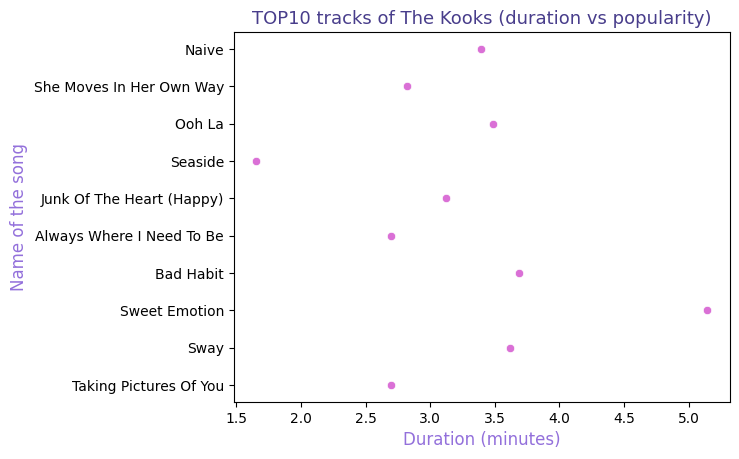

In [124]:
sns.scatterplot(x='duration_minutes', y='name', data=df, color='orchid')
plt.title('TOP10 tracks of The Kooks (duration vs popularity)', fontsize=13, color='darkslateblue')
plt.xlabel('Duration (minutes)', fontsize=12, color='mediumpurple')
plt.ylabel('Name of the song', fontsize=12, color='mediumpurple')
plt.show()

En el gráfico de dispersión se observa la relación entre **la duración de las canciones y los nombres de las canciones del TOP 10**.  
Podemos notar que la canción que ocupa el primer lugar por su duración se encuentra justo en el centro del gráfico, lo que nos lleva a la conclusión de que ha sido exitosa porque no es ni demasiado larga ni demasiado corta: te da tiempo de disfrutarla sin llegar a aburrirte.  
Por otro lado, la canción que dura más de cinco minutos, titulada *"Sweet Emotion"*, aparece al final de la lista del TOP 10.  
También podemos observar que la mayoría de los puntos se concentran en la parte central del gráfico, lo que indica que la duración promedio de las canciones se encuentra entre ***2,5 y 3,5 minutos***.  